In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
file_path = '/content/drive/MyDrive/Data/kaggle-dual-fuel-data/dual_fuel_engine_dataset.csv'

In [ ]:
import pandas as pd

df = pd.read_csv(file_path)
print(df.head())  # Show the first few rows
print("Dataset shape (rows, columns):", df.shape)

   Engine_Load_Percent  Diesel_Energy_Share  Injection_Timing  \
0                   25                30.80              -8.7   
1                   75                72.34             -13.7   
2                  100                70.85              -6.3   
3                  100                58.79             -10.2   
4                   50                61.73              -5.6   

   Fuel_Injection_Pressure  EGR_Rate  Boost_Pressure  Intake_Temperature  \
0                    642.6       1.2            1.72               308.5   
1                    543.1      28.4            2.22               359.5   
2                   1169.1      10.1            1.94               315.7   
3                    525.3      22.0            2.85               347.6   
4                    558.2      20.7            3.01               300.3   

   Equivalence_Ratio  Cylinder_Pressure_Peak  Combustion_Duration  \
0               0.96                    97.5                 32.4   
1             

# Lasso Regression (single output)

**Predicting diesel energy share**

In [ ]:
# Select features and targets
df_encoded = pd.get_dummies(df, columns=['Combustion_Mode'], drop_first=True)

X = df_encoded.drop(columns=['Diesel_Energy_Share'])  # Features
y = df_encoded['Diesel_Energy_Share']               # Target

In [ ]:
# Split data
from sklearn.model_selection import train_test_split

# First split: Separate out 10% for validation
X_temp, X_val, y_temp, y_val = train_test_split(X, y, test_size=0.1, random_state=42)

# Second split: From remaining 90%, split into train/test (80/20)
X_train, X_test, y_train, y_test = train_test_split(X_temp, y_temp, test_size=0.2, random_state=42)

#Old code: X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.linear_model import Lasso
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

# Build and train Lasso model
model = make_pipeline(StandardScaler(), Lasso(alpha=0.1))
model.fit(X_train, y_train)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('lasso', Lasso(alpha=0.1))])

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

'''y_pred = model.predict(X_test)
print("MSE:", mean_squared_error(y_test, y_pred))
print("R² Score:", r2_score(y_test, y_pred))'''

y_pred_test = model.predict(X_test)
print("\n--- Test Set Performance ---")
print("MSE:", mean_squared_error(y_test, y_pred_test))
print("R² Score:", r2_score(y_test, y_pred_test))

y_pred_val = model.predict(X_val)
print("\n--- Validation Set Performance ---")
print("MSE:", mean_squared_error(y_val, y_pred_val))
print("R² Score:", r2_score(y_val, y_pred_val))


--- Test Set Performance ---
MSE: 0.010639828659720315
R² Score: 0.9999480005759341

--- Validation Set Performance ---
MSE: 0.01098324452133847
R² Score: 0.999947423790895


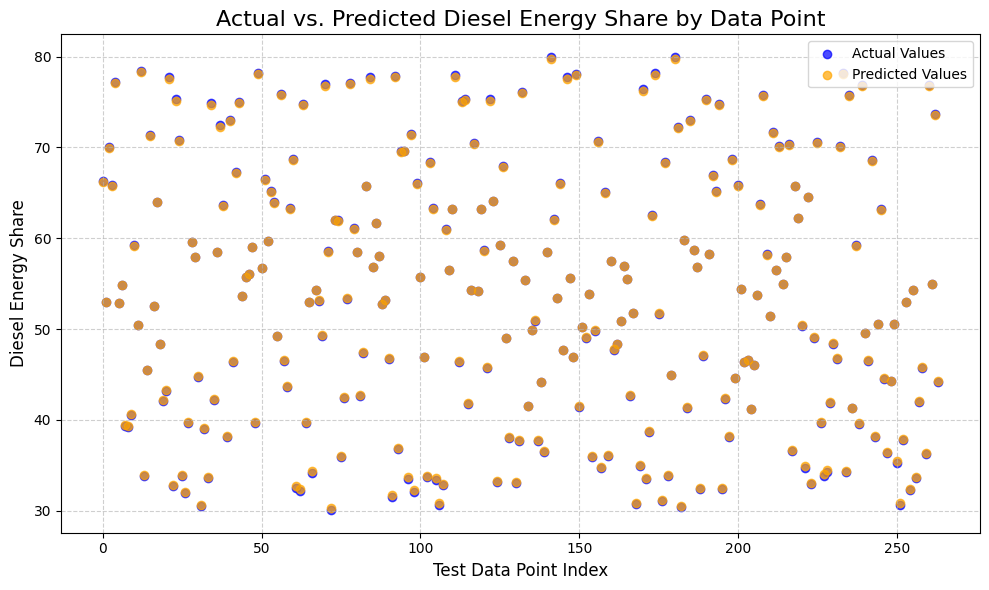

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Get predictions
y_pred = model.predict(X_test)

# Create a plot to visualize the actual vs. predicted values for each data point.
plt.figure(figsize=(10, 6))

# Get the indices of the test set for the x-axis.
x_indices = np.arange(len(y_test))

# Plot the actual values as blue dots.
plt.scatter(x_indices, y_test, color='blue', label='Actual Values', alpha=0.7)

# Plot the predicted values as orange dots.
# This makes it easy to see how close the prediction is for each point.
plt.scatter(x_indices, y_pred, color='orange', label='Predicted Values', alpha=0.7)

plt.title('Actual vs. Predicted Diesel Energy Share by Data Point', fontsize=16)
plt.xlabel('Test Data Point Index', fontsize=12)
plt.ylabel('Diesel Energy Share', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

**Predicting gasoline energy share**

In [ ]:
X1 = df_encoded.drop(columns=['Gasoline_Energy_Share'])  # Features (all values except gasoline energy share)
y1 = df_encoded['Gasoline_Energy_Share']               # Target

# Split data
from sklearn.model_selection import train_test_split

# First split: Separate out 10% for validation
X1_temp, X1_val, y1_temp, y1_val = train_test_split(X1, y1, test_size=0.1, random_state=42)

# Second split: From remaining 90%, split into train/test (80/20)
X1_train, X1_test, y1_train, y1_test = train_test_split(X1_temp, y1_temp, test_size=0.2, random_state=42)

# Old code: X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, test_size=0.2, random_state=42)

# Build and train Lasso model
model = make_pipeline(StandardScaler(), Lasso(alpha=0.1))
model.fit(X1_train, y1_train)

'''y1_pred = model.predict(X1_test)
print("MSE:", mean_squared_error(y1_test, y1_pred))
print("R² Score:", r2_score(y1_test, y1_pred))'''

y1_pred_test = model.predict(X1_test)
print("\n--- Test Set Performance ---")
print("MSE:", mean_squared_error(y1_test, y1_pred_test))
print("R² Score:", r2_score(y1_test, y1_pred_test))

y1_pred_val = model.predict(X1_val)
print("\n--- Validation Set Performance ---")
print("MSE:", mean_squared_error(y1_val, y1_pred_val))
print("R² Score:", r2_score(y1_val, y1_pred_val))


--- Test Set Performance ---
MSE: 0.010639828659720164
R² Score: 0.9999480005759341

--- Validation Set Performance ---
MSE: 0.010983244521338333
R² Score: 0.999947423790895


# Random Forest regressor (single output)

Predicting diesel engine share

In [ ]:
from sklearn.ensemble import RandomForestRegressor

model_rf = make_pipeline(StandardScaler(), RandomForestRegressor(n_estimators=100, random_state=42))
model_rf.fit(X_train, y_train)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('randomforestregressor',
                 RandomForestRegressor(random_state=42))])

In [ ]:
'''y_pred = model_rf.predict(X_test)
print("MSE:", mean_squared_error(y_test, y_pred))
print("R² Score:", r2_score(y_test, y_pred))'''

y_pred_test = model_rf.predict(X_test)
print("\n--- Test Set Performance ---")
print("MSE:", mean_squared_error(y_test, y_pred_test))
print("R² Score:", r2_score(y_test, y_pred_test))

y_pred_val = model_rf.predict(X_val)
print("\n--- Validation Set Performance ---")
print("MSE:", mean_squared_error(y_val, y_pred_val))
print("R² Score:", r2_score(y_val, y_pred_val))


--- Test Set Performance ---
MSE: 0.0028658151893940663
R² Score: 0.9999859940658733

--- Validation Set Performance ---
MSE: 0.002899298503401319
R² Score: 0.999986121211808


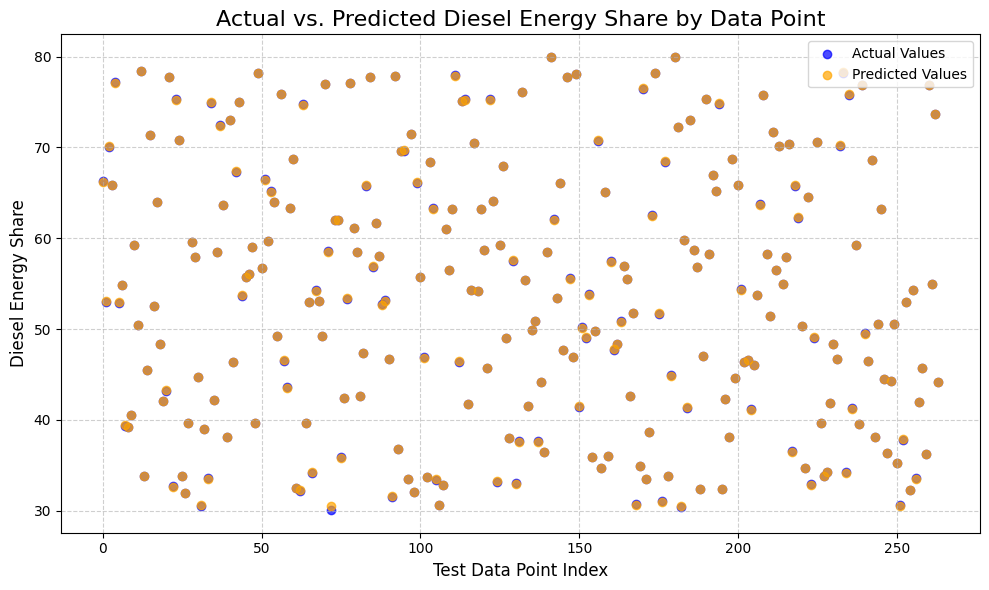

In [ ]:
# Get predictions
y_pred = model_rf.predict(X_test)

# Create a plot to visualize the actual vs. predicted values for each data point.
plt.figure(figsize=(10, 6))

# Get the indices of the test set for the x-axis.
x_indices = np.arange(len(y_test))

# Plot the actual values as blue dots.
plt.scatter(x_indices, y_test, color='blue', label='Actual Values', alpha=0.7)

# Plot the predicted values as orange dots.
# This makes it easy to see how close the prediction is for each point.
plt.scatter(x_indices, y_pred, color='orange', label='Predicted Values', alpha=0.7)

plt.title('Actual vs. Predicted Diesel Energy Share by Data Point', fontsize=16)
plt.xlabel('Test Data Point Index', fontsize=12)
plt.ylabel('Diesel Energy Share', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

Predicting gasoline energy share

In [ ]:
model_rf = make_pipeline(StandardScaler(), RandomForestRegressor(n_estimators=100, random_state=42))

X1_temp, X1_val, y1_temp, y1_val = train_test_split(X1, y1, test_size=0.1, random_state=42)

X1_train, X1_test, y1_train, y1_test = train_test_split(X1_temp, y1_temp, test_size=0.2, random_state=42)

model_rf.fit(X1_train, y1_train)

'''y1_pred = model_rf.predict(X1_test)
print("MSE:", mean_squared_error(y1_test, y1_pred))
print("R² Score:", r2_score(y1_test, y1_pred))'''

y1_pred_test = model_rf.predict(X1_test)
print("\n--- Test Set Performance ---")
print("MSE:", mean_squared_error(y1_test, y1_pred_test))
print("R² Score:", r2_score(y1_test, y1_pred_test))

y1_pred_val = model_rf.predict(X1_val)
print("\n--- Validation Set Performance ---")
print("MSE:", mean_squared_error(y1_val, y1_pred_val))
print("R² Score:", r2_score(y1_val, y1_pred_val))


--- Test Set Performance ---
MSE: 0.0029677465909091257
R² Score: 0.9999854959023837

--- Validation Set Performance ---
MSE: 0.0028604891156464142
R² Score: 0.9999863069902892


# Lasso regression (multiple outputs)

In [ ]:
from sklearn.multioutput import MultiOutputRegressor

X_multiple = df_encoded.drop(columns=['Diesel_Energy_Share', 'Gasoline_Energy_Share'])
y_multiple = df_encoded[['Diesel_Energy_Share', 'Gasoline_Energy_Share']]

X_train_multiple, X_test_multiple, y_train_multiple, y_test_multiple = train_test_split(X_multiple, y_multiple, test_size=0.2, random_state=42)

model_multiple = make_pipeline(StandardScaler(), MultiOutputRegressor(Lasso(alpha=0.1)))
model_multiple.fit(X_train_multiple, y_train_multiple)

y_pred_multiple = model_multiple.predict(X_test_multiple)

print("MSE:", mean_squared_error(y_test_multiple, y_pred_multiple))
print("R² Score:", r2_score(y_test_multiple, y_pred_multiple))

MSE: 207.4400060793269
R² Score: -0.017254074768476402


In [ ]:
mse = mean_squared_error(y_test_multiple, y_pred_multiple, multioutput='raw_values')
r2 = r2_score(y_test_multiple, y_pred_multiple, multioutput='raw_values')

print("\n================= Multi-Output Model Performance Metrics =================")
print(f"Mean Squared Error (MSE) for Diesel_Energy_Share: {mse[0]:.4f}")
print(f"Mean Squared Error (MSE) for Gasoline_Energy_Share: {mse[1]:.4f}")
print("-------------------------------------------------------------------------")
print(f"R² Score for Diesel_Energy_Share: {r2[0]:.4f}")
print(f"R² Score for Gasoline_Energy_Share: {r2[1]:.4f}")
print("==========================================================================")


================= Multi-Output Model Performance Metrics =================
Mean Squared Error (MSE) for Diesel_Energy_Share: 207.4400
Mean Squared Error (MSE) for Gasoline_Energy_Share: 207.4400
-------------------------------------------------------------------------
R² Score for Diesel_Energy_Share: -0.0173
R² Score for Gasoline_Energy_Share: -0.0173


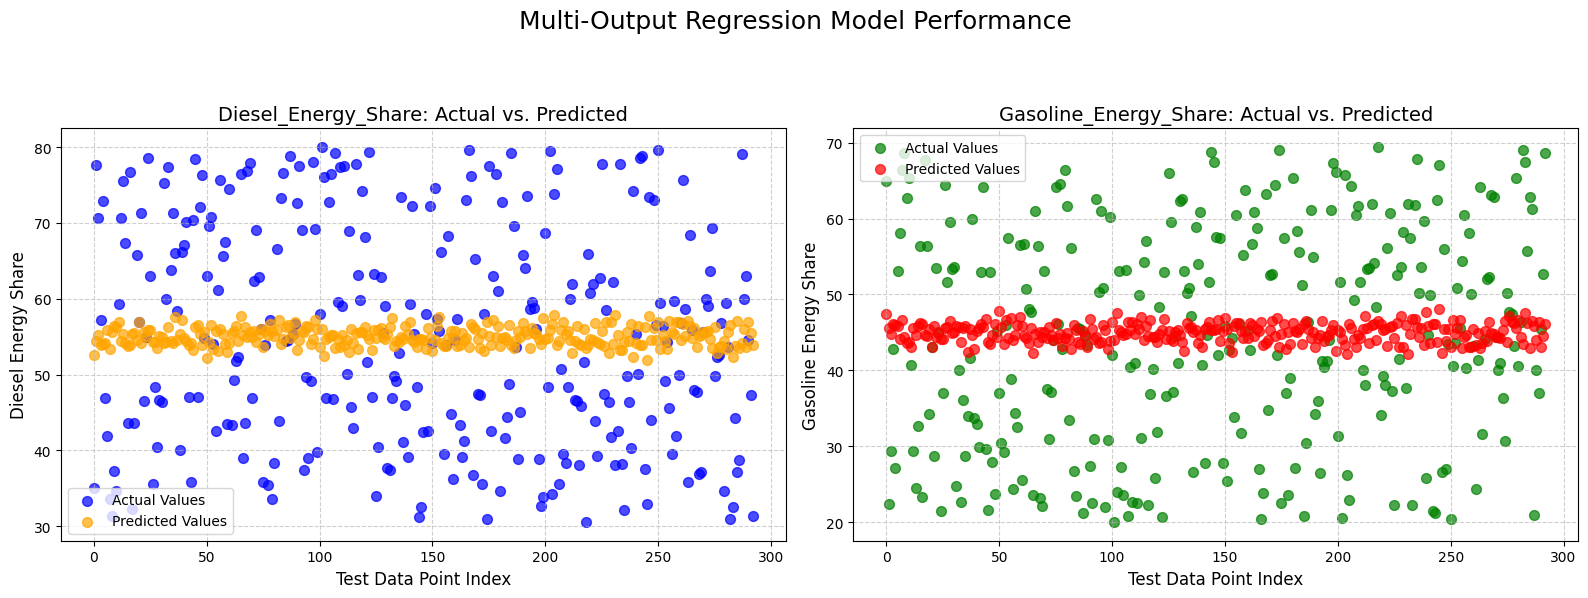

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

x_indices = np.arange(len(y_test_multiple))

ax1.scatter(x_indices, y_test_multiple['Diesel_Energy_Share'], color='blue', label='Actual Values', alpha=0.7, s=50)
ax1.scatter(x_indices, y_pred_multiple[:, 0], color='orange', label='Predicted Values', alpha=0.7, s=50)
ax1.set_title('Diesel_Energy_Share: Actual vs. Predicted', fontsize=14)
ax1.set_xlabel('Test Data Point Index', fontsize=12)
ax1.set_ylabel('Diesel Energy Share', fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.legend()

ax2.scatter(x_indices, y_test_multiple['Gasoline_Energy_Share'], color='green', label='Actual Values', alpha=0.7, s=50)
ax2.scatter(x_indices, y_pred_multiple[:, 1], color='red', label='Predicted Values', alpha=0.7, s=50)
ax2.set_title('Gasoline_Energy_Share: Actual vs. Predicted', fontsize=14)
ax2.set_xlabel('Test Data Point Index', fontsize=12)
ax2.set_ylabel('Gasoline Energy Share', fontsize=12)
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.legend()

plt.suptitle('Multi-Output Regression Model Performance', fontsize=18, y=1.02)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Random Forest regressor (multiple outputs)

In [ ]:
model_rf_multiple = make_pipeline(StandardScaler(), MultiOutputRegressor(RandomForestRegressor(n_estimators=100, random_state=42)))
model_rf_multiple.fit(X_train_multiple, y_train_multiple)

y_rf_pred_multiple = model_multiple.predict(X_test_multiple)

print("MSE:", mean_squared_error(y_test_multiple, y_pred_multiple))
print("R² Score:", r2_score(y_test_multiple, y_pred_multiple))

MSE: 207.4400060793269
R² Score: -0.017254074768476402
